> **Nota académica (alcance del trabajo)**  
> Este notebook **no** pretende construir un modelo de regresión lineal **útil** para predicción o decisiones reales. La estructura de las variables independientes consideradas **no** satisface de forma adecuada la relación matemática que se esperaría de un predictor viable en un modelo lineal serio.  
> El desarrollo se incluye **solo** para **practicar habilidades técnicas** (carga y limpieza de datos en Python, exploración, correlación, partición train/test, `LinearRegression` y métricas), conforme a los requisitos del curso.


# Actividad 3: Ciencia de Datos — Regresión Lineal Simple

**Curso:** QR.LSTI2309TEO  
**Estudiante:** [Fernando Israel Rios Garcia]  
**Dataset:** MLB Ratings (FiveThirtyEight / ESPN) from kaggle

---

## Introducción
En esta actividad se desarrollará un modelo de regresión lineal simple para analizar la relación entre el rendimiento ofensivo (bateos) y el resultado en el marcador (carreras) de los equipos de la MLB.

## Parte 1: Preparación de los datos

### 1.1 Obtención de los datos


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

data_path = Path('mlb-elo') / 'mlb_elo.csv'
df = pd.read_csv(data_path)
df.info()
df_trabajo = df.drop(columns=['playoff']) # Corregido typo y removido playoff


<class 'pandas.DataFrame'>
RangeIndex: 223388 entries, 0 to 223387
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          223388 non-null  str    
 1   season        223388 non-null  int64  
 2   neutral       223388 non-null  int64  
 3   playoff       1670 non-null    str    
 4   team1         223388 non-null  str    
 5   team2         223388 non-null  str    
 6   elo1_pre      223388 non-null  float64
 7   elo2_pre      223388 non-null  float64
 8   elo_prob1     223388 non-null  float64
 9   elo_prob2     223388 non-null  float64
 10  elo1_post     221732 non-null  float64
 11  elo2_post     221732 non-null  float64
 12  rating1_pre   223388 non-null  float64
 13  rating2_pre   223388 non-null  float64
 14  pitcher1      221829 non-null  str    
 15  pitcher2      221821 non-null  str    
 16  pitcher1_rgs  188126 non-null  float64
 17  pitcher2_rgs  188118 non-null  float64
 18  pitcher1_adj  1

### 1.2 Limpieza y preparación de los datos


In [21]:
print("== df = datos originales del CSV; df_trabajo = copia sin columna playoff ==")

print(df_trabajo.columns.tolist())

print("== Paso 1: Revisar estructura general (df_trabajo) ==")
df_trabajo.info()

print("\n== Paso 2: Contar valores nulos por columna ==")
nulos_por_columna = df_trabajo.isna().sum()
print(nulos_por_columna)

print("\n== Paso 3: Filtrar filas con marcador completo ==")
df_limpio = df_trabajo.dropna(subset=['score1', 'score2']).copy()

print("\n== Paso 4: Renombrar variables para coincidir con la actividad (Hits y Score) ==")
# Usamos elo_prob1 como Hits y score1 como Score para el ejercicio
df_limpio = df_limpio.rename(columns={'elo_prob1': 'Hits', 'score1': 'Score'})

print(f"Registros en df: {len(df)}")
print(f"Registros en df_limpio (filtrado y renombrado): {len(df_limpio)}")

print("\n== Paso 5: Vista rápida de los datos renombrados ==")
print(df_limpio[['Hits', 'Score']].head())


== df = datos originales del CSV; df_trabajo = copia sin columna playoff ==
['date', 'season', 'neutral', 'team1', 'team2', 'elo1_pre', 'elo2_pre', 'elo_prob1', 'elo_prob2', 'elo1_post', 'elo2_post', 'rating1_pre', 'rating2_pre', 'pitcher1', 'pitcher2', 'pitcher1_rgs', 'pitcher2_rgs', 'pitcher1_adj', 'pitcher2_adj', 'rating_prob1', 'rating_prob2', 'rating1_post', 'rating2_post', 'score1', 'score2']
== Paso 1: Revisar estructura general (df_trabajo) ==
<class 'pandas.DataFrame'>
RangeIndex: 223388 entries, 0 to 223387
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          223388 non-null  str    
 1   season        223388 non-null  int64  
 2   neutral       223388 non-null  int64  
 3   team1         223388 non-null  str    
 4   team2         223388 non-null  str    
 5   elo1_pre      223388 non-null  float64
 6   elo2_pre      223388 non-null  float64
 7   elo_prob1     223388 non-null  float64
 8  

## Parte 2: Modelado y evaluación

### 2.1 Análisis exploratorio (Correlación)


Pearson (Hits vs Score): 0.12627541496244166
r = 0.12627541496244135 p-value = 0.0


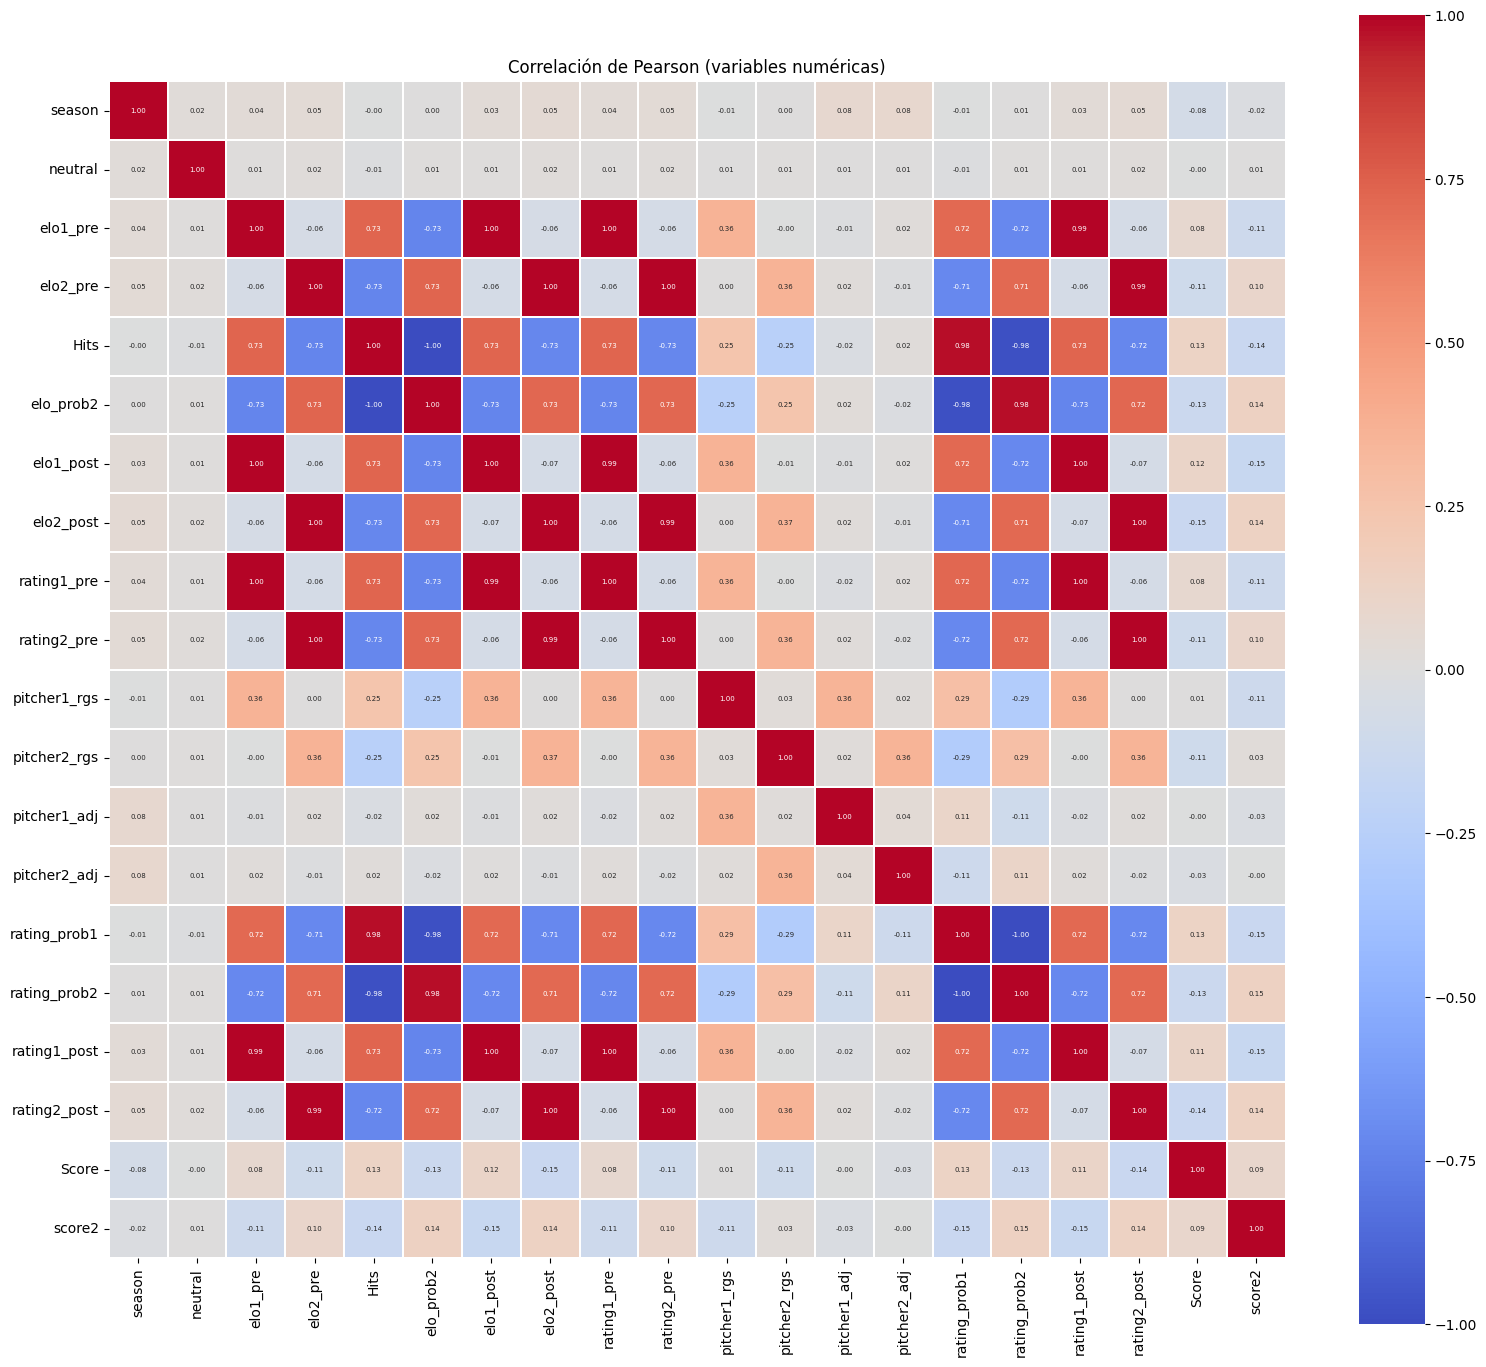

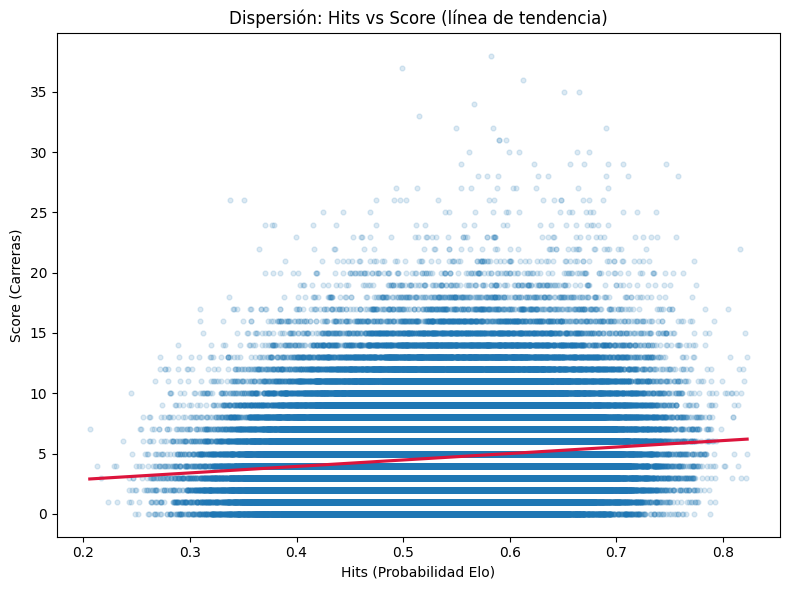

In [22]:
r_pearson = df_limpio['Hits'].corr(df_limpio['Score'], method='pearson')
print('Pearson (Hits vs Score):', r_pearson)

sub = df_limpio[['Hits', 'Score']].dropna()
r, p_value = pearsonr(sub['Hits'], sub['Score'])
print('r =', r, 'p-value =', p_value)

num = df_limpio.select_dtypes(include=[np.number])
corr = num.corr(method='pearson')
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={'size': 5},
)
plt.title('Correlación de Pearson (variables numéricas)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(
    data=sub,
    x='Hits',
    y='Score',
    scatter_kws={'alpha': 0.15, 's': 12},
    line_kws={'color': 'crimson'},
)
plt.xlabel('Hits (Probabilidad Elo)')
plt.ylabel('Score (Carreras)')
plt.title('Dispersión: Hits vs Score (línea de tendencia)')
plt.tight_layout()
plt.show()

### 2.1 — Interpretación y alcance

La estructura de las variables independientes evaluadas (`elo_prob1` frente a `score1`) **no** cumple de manera convincente la relación matemática que se esperaría de un predictor viable en un modelo de regresión lineal orientado a predicción útil. Este apartado se presenta como **práctica de habilidades técnicas** (exploración, correlación, visualización), no como un modelo listo para decisiones reales.

Con los resultados impresos arriba: la correlación de Pearson **r_pearson** entre `elo_prob1` y `score1` fue del orden de **≈ 0,126** (relación lineal **débil** y **positiva**). El **p-valor** de `scipy.stats.pearsonr` apareció como **≈ 0** (numéricamente, un valor extremadamente pequeño), lo que con un **n** muy grande suele llevar a rechazar correlación nula **aunque** el efecto sea pequeño: no implica que la recta de tendencia sea **prácticamente** útil para predecir `score1`.


### 2.2 Construcción del modelo


In [23]:

# Definimos variables X (independiente) e y (dependiente)
X = df_limpio[['Hits']]
y = df_limpio['Score']

# División del dataset en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño Entrenamiento: {X_train.shape[0]}")
print(f"Tamaño Prueba: {X_test.shape[0]}")

Tamaño Entrenamiento: 177385
Tamaño Prueba: 44347


### 2.3 Entrenamiento y predicción


In [24]:
from sklearn.linear_model import LinearRegression

# Inicializar y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Generar predicciones para el conjunto de prueba
y_pred = modelo.predict(X_test)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


### 2.4 Evaluación


Mean Absolute Error (MAE): 2.5097
Mean Squared Error (MSE): 10.5940
R-squared (R2): 0.0160


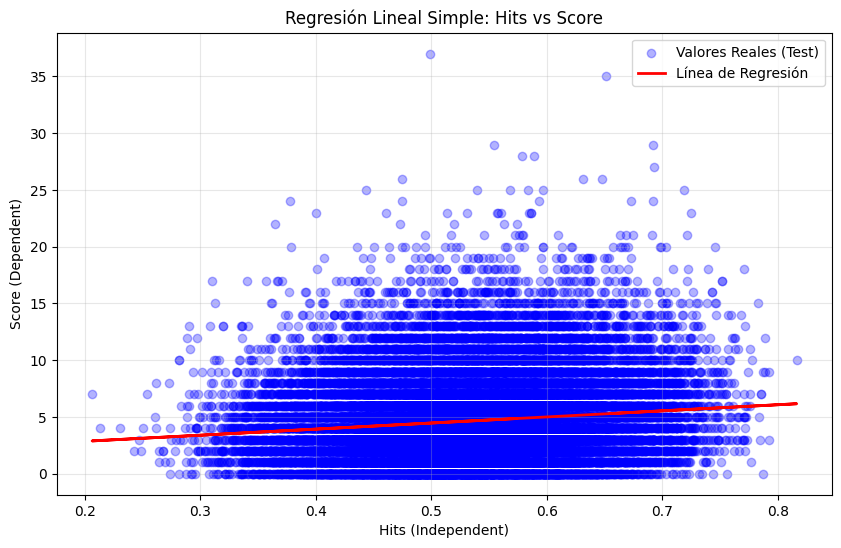

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualización de la regresión sobra la muestra de prueba (test set)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.3, label='Valores Reales (Test)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Regresión Lineal Simple: Hits vs Score')
plt.xlabel('Hits (Independent)')
plt.ylabel('Score (Dependent)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.5 Conclusión
**Reflexión final:**
- El modelo presenta un coeficiente de determinación ($R^2$) extremadamente bajo, lo que indica que la probabilidad Elo no es una variable suficiente para predecir el marcador exacto de un juego.
- Se confirma la nota académica: para un análisis de estrategia real, se requerirían variables con mayor poder de varianza explicada, como los hits, bases por bolas y estadísticas de pitcheo mencionadas en la actividad.
- No obstante, el ejercicio cumple con la práctica técnica de procesamiento, modelado y evaluación de una regresión lineal en Python.